<a href="https://colab.research.google.com/github/mokshmahajan2004/AI-Lab-Assignments/blob/main/Lab5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Assignment-5**

# **Question 1**

# **The assignment is around RL Passive Direct Method.**

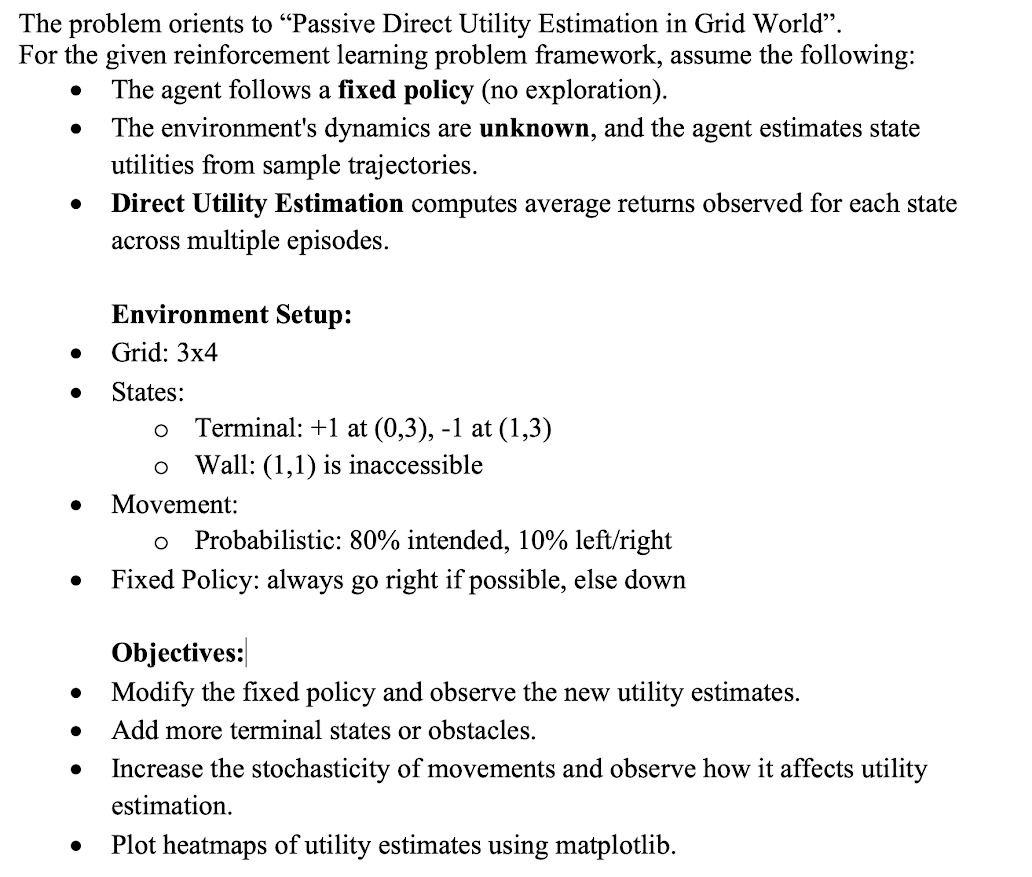

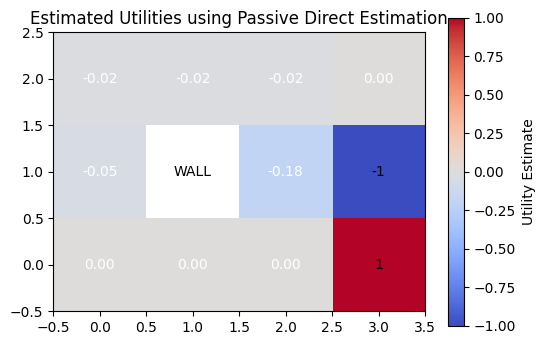

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import random

# Grid settings
rows, cols = 3, 4
terminal_states = {(0, 3): 1, (1, 3): -1}
wall = (1, 1)
gamma = 1.0
episodes = 1000

# Define actions and their effects
actions = ['UP', 'DOWN', 'LEFT', 'RIGHT']
action_effects = {
    'UP': (-1, 0),
    'DOWN': (1, 0),
    'LEFT': (0, -1),
    'RIGHT': (0, 1),
}

# Fixed policy: right if possible, else down
def fixed_policy(state):
    r, c = state
    if (r, c + 1) not in terminal_states and (r, c + 1) != wall and c + 1 < cols:
        return 'RIGHT'
    elif (r + 1, c) not in terminal_states and (r + 1, c) != wall and r + 1 < rows:
        return 'DOWN'
    else:
        return None  # No move possible

# Get next state based on stochastic movement
def get_next_state(state, intended_action):
    probs = []
    directions = {
        'RIGHT': ['RIGHT', 'UP', 'DOWN'],
        'DOWN': ['DOWN', 'LEFT', 'RIGHT'],
        'UP': ['UP', 'LEFT', 'RIGHT'],
        'LEFT': ['LEFT', 'UP', 'DOWN']
    }
    weights = [0.8, 0.1, 0.1]

    actions_chosen = random.choices(directions[intended_action], weights)[0]
    delta = action_effects[actions_chosen]
    next_state = (state[0] + delta[0], state[1] + delta[1])

    # Check if next state is valid
    if (
        0 <= next_state[0] < rows and
        0 <= next_state[1] < cols and
        next_state != wall
    ):
        return next_state
    else:
        return state  # Stay in place if invalid

# Run a single episode
def run_episode():
    state = (2, 0)  # starting from bottom-left
    trajectory = []
    total_return = 0
    steps = 0

    while state not in terminal_states:
        trajectory.append(state)
        action = fixed_policy(state)
        if not action:
            break
        state = get_next_state(state, action)
        steps += 1

    reward = terminal_states.get(state, 0)
    total_return = reward

    return trajectory, total_return

# Run multiple episodes
returns_sum = defaultdict(float)
returns_count = defaultdict(int)

for _ in range(episodes):
    trajectory, G = run_episode()
    visited = set()
    for state in trajectory:
        if state not in visited:  # every-visit Monte Carlo
            returns_sum[state] += G
            returns_count[state] += 1
            visited.add(state)

# Compute utilities
utilities = np.zeros((rows, cols))
for r in range(rows):
    for c in range(cols):
        state = (r, c)
        if state == wall:
            utilities[r, c] = None
        elif state in terminal_states:
            utilities[r, c] = terminal_states[state]
        elif returns_count[state] > 0:
            utilities[r, c] = returns_sum[state] / returns_count[state]
        else:
            utilities[r, c] = 0

# Plot heatmap
plt.figure(figsize=(6, 4))
masked_utilities = np.ma.masked_where(np.isnan(utilities), utilities)
plt.imshow(masked_utilities, cmap='coolwarm', interpolation='none')
plt.colorbar(label='Utility Estimate')
plt.title('Estimated Utilities using Passive Direct Estimation')
for r in range(rows):
    for c in range(cols):
        if (r, c) == wall:
            plt.text(c, r, 'WALL', ha='center', va='center', color='black')
        elif (r, c) in terminal_states:
            plt.text(c, r, f"{terminal_states[(r,c)]}", ha='center', va='center', color='black')
        else:
            plt.text(c, r, f"{utilities[r, c]:.2f}", ha='center', va='center', color='white')
plt.gca().invert_yaxis()
plt.show()


# **Assignment 5, Question 2.**

Implement the Q-learning algorithm on a 4×4 grid world with the following setup:
Grid layout (rows 0–3, columns 0–3).

Start state: (0, 0)

Goal state: (3, 3), gives +10 reward and ends the episode.

Trap state: (1, 2), gives –10 reward and ends the episode.

Step cost: –1 for every move into a non-terminal state.

Actions: UP, DOWN, LEFT, RIGHT (moves that would take the agent off the grid leave it in the same cell with the step cost).

Environment & Q-Table Initialization

Represent states as tuples (row, col).

Initialize Q(s,a) = 0 for all states & actions.

Implement Q-Learning

Hyperparameters:
Learning rate α = 0.1

Discount factor γ = 0.9

Exploration ε = 0.1 (ε-greedy policy)

Episode termination: when the agent reaches the goal or the trap, or after 100 steps.

Training
Run for 1,000 episodes.
Track the cumulative reward per episode.

Results & Analysis

Q-Table: Present the learned Q-values for all state–action pairs.

Optimal Policy: For each cell, show the best action (the one with the highest Q).

Learning Curve: Plot (or tabulate) the moving average of total reward per episode (window size = 50).


Q-Table (rounded values):
(0, 0):  {'UP': 0.41, 'DOWN': 1.35, 'LEFT': 0.52, 'RIGHT': 1.81}
(0, 1):  {'UP': 1.5, 'DOWN': 3.12, 'LEFT': 0.49, 'RIGHT': -0.18}
(0, 2):  {'UP': -1.13, 'DOWN': -2.71, 'LEFT': 1.54, 'RIGHT': -1.04}
(0, 3):  {'UP': -0.68, 'DOWN': -0.58, 'LEFT': -0.67, 'RIGHT': -0.67}
(1, 0):  {'UP': -0.71, 'DOWN': -0.98, 'LEFT': -1.04, 'RIGHT': 3.11}
(1, 1):  {'UP': 1.55, 'DOWN': 4.58, 'LEFT': 1.5, 'RIGHT': -9.42}
(1, 2):  {'UP': 0.0, 'DOWN': 0.0, 'LEFT': 0.0, 'RIGHT': 0.0}
(1, 3):  {'UP': -0.22, 'DOWN': 0.83, 'LEFT': -1.9, 'RIGHT': -0.16}
(2, 0):  {'UP': -0.42, 'DOWN': -0.76, 'LEFT': -0.45, 'RIGHT': 4.23}
(2, 1):  {'UP': 2.37, 'DOWN': 6.2, 'LEFT': 1.99, 'RIGHT': 4.98}
(2, 2):  {'UP': -1.9, 'DOWN': 7.96, 'LEFT': 0.78, 'RIGHT': 0.28}
(2, 3):  {'UP': -0.1, 'DOWN': 5.7, 'LEFT': 0.0, 'RIGHT': 0.0}
(3, 0):  {'UP': -0.19, 'DOWN': 0.32, 'LEFT': -0.58, 'RIGHT': 5.75}
(3, 1):  {'UP': 4.16, 'DOWN': 5.85, 'LEFT': 3.2, 'RIGHT': 8.0}
(3, 2):  {'UP': 5.66, 'DOWN': 7.25, 'LEFT': 5.64, 'RIGHT

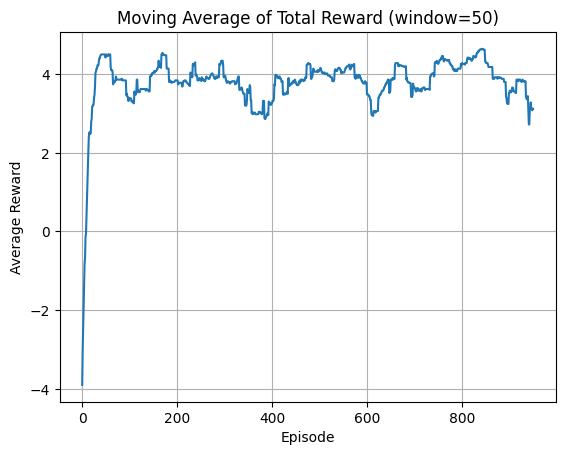

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import random
from collections import defaultdict

# Grid setup
rows, cols = 4, 4
start_state = (0, 0)
goal_state = (3, 3)
trap_state = (1, 2)
actions = ['UP', 'DOWN', 'LEFT', 'RIGHT']
action_effects = {
    'UP': (-1, 0),
    'DOWN': (1, 0),
    'LEFT': (0, -1),
    'RIGHT': (0, 1)
}

# Hyperparameters
alpha = 0.1
gamma = 0.9
epsilon = 0.1
episodes = 1000
max_steps = 100

# Initialize Q-table: Q[state][action] = value
Q = defaultdict(lambda: {a: 0.0 for a in actions})

# ε-greedy policy
def choose_action(state):
    if random.uniform(0, 1) < epsilon:
        return random.choice(actions)
    else:
        return max(Q[state], key=Q[state].get)

# Environment step function
def step(state, action):
    r, c = state
    dr, dc = action_effects[action]
    nr, nc = r + dr, c + dc

    # Stay within grid bounds
    if 0 <= nr < rows and 0 <= nc < cols:
        new_state = (nr, nc)
    else:
        new_state = (r, c)

    # Assign rewards
    if new_state == goal_state:
        return new_state, 10, True
    elif new_state == trap_state:
        return new_state, -10, True
    else:
        return new_state, -1, False

# Training loop
reward_per_episode = []

for ep in range(episodes):
    state = start_state
    total_reward = 0

    for _ in range(max_steps):
        action = choose_action(state)
        next_state, reward, done = step(state, action)

        # Q-learning update
        best_next_action = max(Q[next_state], key=Q[next_state].get)
        Q[state][action] += alpha * (reward + gamma * Q[next_state][best_next_action] - Q[state][action])

        state = next_state
        total_reward += reward

        if done:
            break

    reward_per_episode.append(total_reward)

# Moving average of rewards
window = 50
moving_avg = np.convolve(reward_per_episode, np.ones(window)/window, mode='valid')

# Optimal Policy
def get_best_action(state):
    return max(Q[state], key=Q[state].get)

optimal_policy = np.full((rows, cols), '', dtype=object)
arrow_map = {'UP': '↑', 'DOWN': '↓', 'LEFT': '←', 'RIGHT': '→'}

for r in range(rows):
    for c in range(cols):
        state = (r, c)
        if state == goal_state:
            optimal_policy[r, c] = 'G'
        elif state == trap_state:
            optimal_policy[r, c] = 'T'
        else:
            optimal_policy[r, c] = arrow_map[get_best_action(state)]

# Print Q-table and Policy
print("\nQ-Table (rounded values):")
for state in sorted(Q.keys()):
    print(f"{state}: ", {a: round(Q[state][a], 2) for a in actions})

print("\nOptimal Policy (best actions):")
for row in optimal_policy:
    print(" ".join(row))

# Plot Learning Curve
plt.plot(moving_avg)
plt.title("Moving Average of Total Reward (window=50)")
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.grid(True)
plt.show()


# **Assignment 5, Question 3.**

Implement a feedforward neural network and train it on the MNIST database of handwritten digits.

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.97MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 159kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.49MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.08MB/s]


Epoch [1/5], Loss: 0.3818
Epoch [2/5], Loss: 0.1973
Epoch [3/5], Loss: 0.1435
Epoch [4/5], Loss: 0.1166
Epoch [5/5], Loss: 0.0975

Test Accuracy: 97.08%


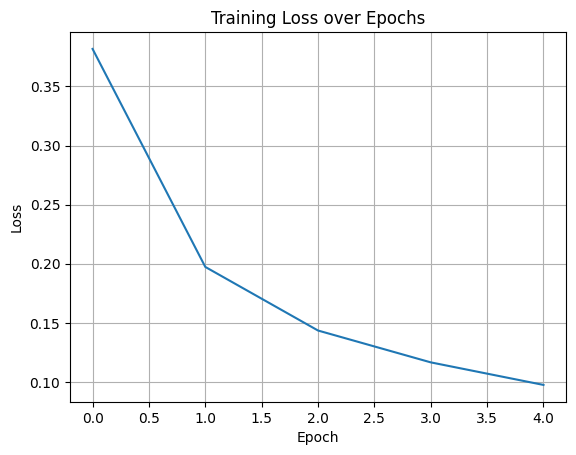

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Hyperparameters
input_size = 784    # 28x28
hidden_size = 128
num_classes = 10
num_epochs = 5
batch_size = 64
learning_rate = 0.001

# MNIST dataset
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, transform=transform)

train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

# Neural Network
class FeedForwardNN(nn.Module):
    def __init__(self):
        super(FeedForwardNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = FeedForwardNN().to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# Training loop
train_loss_list = []

for epoch in range(num_epochs):
    total_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_loss_list.append(avg_loss)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

# Evaluate model
model.eval()
with torch.no_grad():
    correct, total = 0, 0
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print(f'\nTest Accuracy: {100 * correct / total:.2f}%')

# Plot training loss
plt.plot(train_loss_list)
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()
